In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import xarray as xr
from dataclasses import dataclass
from collections import defaultdict
from pathlib import Path
from scipy.spatial import cKDTree
from typing import Dict, List, Tuple


In [10]:
ds=xr.open_dataset("/mnt/weatherloss/WindPower/inference/EGU/NoPowerLarge/forecast_20240801000000.nc")

/mnt/weatherloss/WindPower/conda_envs/windpower312/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/mnt/weatherloss/WindPower/conda_envs/windpower312/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/mnt/weatherloss/WindPower/conda_envs/windpower312/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/mnt/weatherloss/WindPower/conda_envs/windpower312/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_5

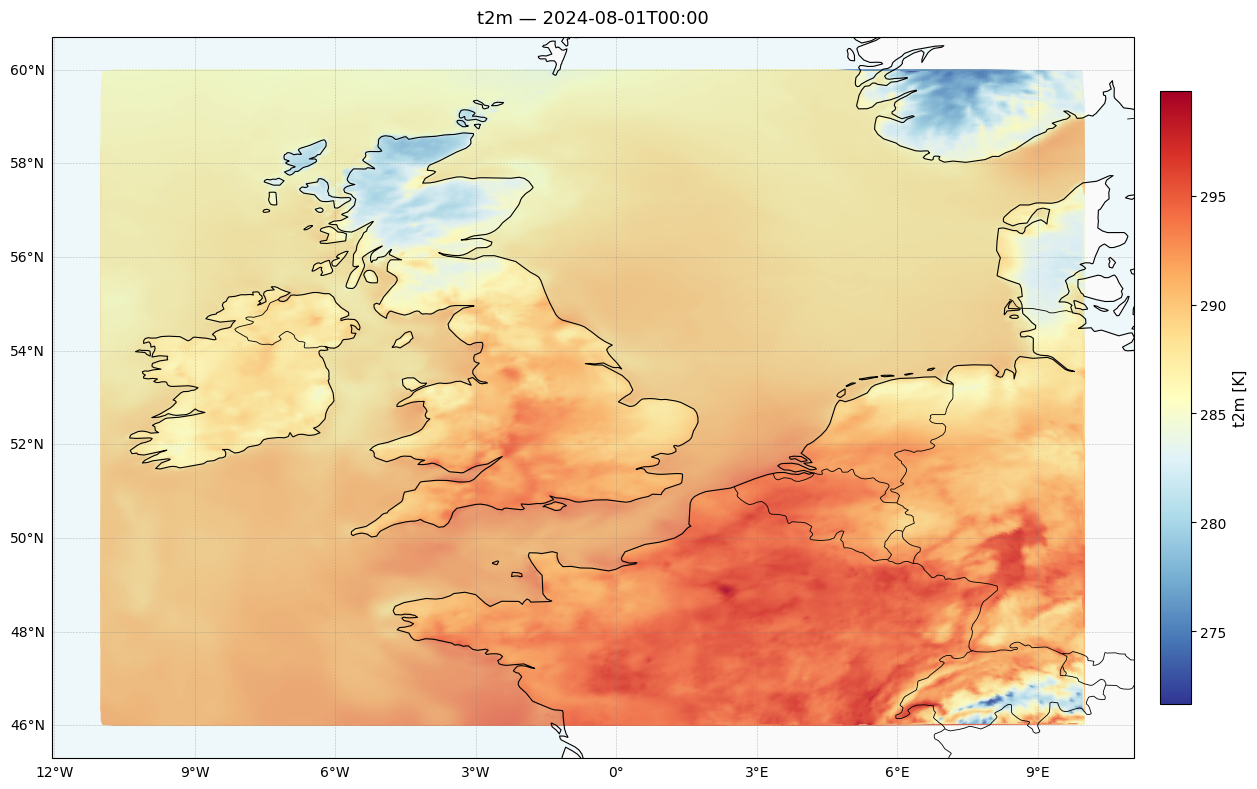

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_dataset_variable(ds, var_name="t2m", time_idx=0, cmap="RdYlBu_r"):
    """
    Plot a variable from the xarray Dataset on a 2D map with country boundaries.
    
    Args:
        ds: xarray.Dataset with latitude, longitude, and the target variable
        var_name: name of the variable to plot (default: 't2m')
        time_idx: time index to plot (0-24 for your dataset)
        cmap: matplotlib colormap
    """
    lats = ds["latitude"].values
    lons = ds["longitude"].values
    data = ds[var_name].isel(time=time_idx).values
    time_label = str(ds["time"].values[time_idx])[:16]

    fig, ax = plt.subplots(
        figsize=(14, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    # Use tripcolor for unstructured/irregular grids (fast & interpolates triangles)
    triang = tri.Triangulation(lons, lats)
    tcf = ax.tripcolor(
        triang, data,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        shading="gouraud",  # smooth interpolation
        rasterized=True
    )

    # Country boundaries & coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="black", zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black", zorder=5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.1, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2, zorder=1)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                      alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    # Colorbar
    cbar = plt.colorbar(tcf, ax=ax, orientation="vertical",
                        pad=0.02, fraction=0.025, shrink=0.85)
    cbar.set_label(f"{var_name} [{get_units(var_name)}]", fontsize=11)

    ax.set_title(f"{var_name} — {time_label}", fontsize=13, pad=10)
    plt.tight_layout()
    plt.savefig(f"{var_name}_{time_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()


def get_units(var_name):
    units = {
        "t2m": "K", "msl": "Pa", "ws10": "m/s", "ws100": "m/s",
        "mcc": "fraction",
    }
    for prefix in ["t_", "q_", "u_", "v_", "z_"]:
        if var_name.startswith(prefix):
            return {"t_": "K", "q_": "kg/kg", "u_": "m/s",
                    "v_": "m/s", "z_": "m²/s²"}[prefix]
    return units.get(var_name, "")



# Plot 2m temperature at first time step
plot_dataset_variable(ds, var_name="t2m", time_idx=0)


In [12]:
xr.open_dataset("/mnt/weatherloss/WindPower/data/EGU26/filledpower.zarr")

<xarray.Dataset> Size: 11GB
Dimensions:    (time: 31408, y: 308, x: 293)
Coordinates:
  * time       (time) datetime64[ns] 251kB 2015-01-01 ... 2025-09-30T21:00:00
    latitude   (y, x) float64 722kB ...
    longitude  (y, x) float64 722kB ...
Dimensions without coordinates: y, x
Data variables:
    power      (time, y, x) float32 11GB ...

## Fill NaNs with Power

In [2]:
# Cell 2 — Paths and config
SOURCE_ZARR   = Path("/mnt/weatherloss/WindPower/data/EGU26/cerra_EGULarge_xy.zarr")
OUT_ZARR      = Path("/mnt/weatherloss/WindPower/data/EGU26/filledpower.zarr")

METADATA_PATH = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv")
COUNTS_PATH   = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/wind_farm_turbine_counts.csv")
SPECS_PATH    = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/turbine_specs.csv")

MAX_SNAP_KM = 4.0

In [3]:

@dataclass(frozen=True)
class TurbineSpec:
    cut_in:      float
    rated_ws:    float
    cut_out:     float
    rated_power: float  # MW per turbine


def power_curve(ws: np.ndarray, spec: TurbineSpec) -> np.ndarray:
    ws  = np.asarray(ws, dtype=float)
    out = np.zeros_like(ws, dtype=np.float32)

    denom = spec.rated_ws**3 - spec.cut_in**3
    a     = 1.0 / denom
    b     = spec.cut_in**3 / denom

    ramp = (ws >= spec.cut_in) & (ws < spec.rated_ws)
    out[ramp] = spec.rated_power * (a * ws[ramp]**3 - b)

    rated = (ws >= spec.rated_ws) & (ws < spec.cut_out)
    out[rated] = spec.rated_power

    return out


def load_specs(path: Path) -> Dict[str, TurbineSpec]:
    df = pd.read_csv(path)
    return {
        row["turbine_type (name-capacity-type)"]: TurbineSpec(
            cut_in      = float(row["cut_in_ms"]),
            rated_ws    = float(row["rated_ws_ms"]),
            cut_out     = float(row["cut_out_ms"]),
            rated_power = float(row["rated_power_mw"]),
        )
        for _, row in df.iterrows()
    }

In [4]:
# Cell 4 — Snap every farm to the nearest CERRA (y, x) cell,
# with manual overrides for farms that land on the wrong side
# of a cell boundary (verified against turbinemask).

# Correction map: farm name → (correct_y, correct_x)
# These 6 farms were off by 1 cell due to floating-point tie-breaking.
SNAP_OVERRIDES = {
    "Norther Offshore WP":  (113, 201),
    "BurboBank":             (161, 130),
    "BurboBankExtension":    (161, 130),
    "HumberGateway":         (159, 172),
    "RaceBank":              (150, 177),
    "Walney1":               (172, 127),
    "Walney2":               (172, 127),
}


def latlon_to_xy_km(lon, lat):
    """Flat-Earth projection to km — good enough for snapping over the North Sea."""
    R    = 6371.0
    lat0 = np.deg2rad(np.mean(lat))
    x_km = R * np.deg2rad(np.asarray(lon)) * np.cos(lat0)
    y_km = R * np.deg2rad(np.asarray(lat))
    return np.column_stack([x_km, y_km])


def snap_farms_to_cerra(
    meta:      pd.DataFrame,
    cerra_lat: np.ndarray,
    cerra_lon: np.ndarray,
    max_km:    float,
) -> pd.DataFrame:
    flat_lat = cerra_lat.ravel()
    flat_lon = cerra_lon.ravel()
    grid_pts = latlon_to_xy_km(flat_lon, flat_lat)
    farm_pts = latlon_to_xy_km(meta["lon"].values, meta["lat"].values)

    tree      = cKDTree(grid_pts)
    dist, idx = tree.query(farm_pts, k=1)

    ny, nx = cerra_lat.shape
    snap_y = idx // nx
    snap_x = idx %  nx

    bad = dist > max_km
    if bad.any():
        for i in np.where(bad)[0]:
            print(f"  WARNING: {meta.iloc[i]['farm']} is {dist[i]:.2f} km from nearest CERRA cell")
        raise ValueError(f"{bad.sum()} farm(s) exceed max snap distance {max_km} km")

    meta = meta.copy()
    meta["snap_y"]       = snap_y
    meta["snap_x"]       = snap_x
    meta["snap_dist_km"] = dist

    # Apply manual overrides
    n_overridden = 0
    for i, row in meta.iterrows():
        if row["farm"] in SNAP_OVERRIDES:
            old = (int(meta.at[i, "snap_y"]), int(meta.at[i, "snap_x"]))
            new = SNAP_OVERRIDES[row["farm"]]
            meta.at[i, "snap_y"] = new[0]
            meta.at[i, "snap_x"] = new[1]
            print(f"  Override: {row['farm']:30s} {old} → {new}")
            n_overridden += 1
    print(f"  {n_overridden} farms overridden.")

    return meta

# --- Run it ---
ds = xr.open_zarr(SOURCE_ZARR, consolidated=False)

meta = pd.read_csv(METADATA_PATH)
meta = snap_farms_to_cerra(
    meta,
    cerra_lat = ds["latitude"].values,
    cerra_lon = ds["longitude"].values,
    max_km    = 4.5,
)

print()
print(meta[["farm", "lat", "lon", "snap_y", "snap_x", "snap_dist_km"]].to_string())

  Override: Norther Offshore WP            (113, 202) → (113, 201)
  Override: BurboBank                      (161, 129) → (161, 130)
  Override: BurboBankExtension             (161, 129) → (161, 130)
  Override: HumberGateway                  (158, 172) → (159, 172)
  Override: RaceBank                       (150, 178) → (150, 177)
  Override: Walney1                        (173, 127) → (172, 127)
  Override: Walney2                        (173, 127) → (172, 127)
  7 farms overridden.

                                farm        lat       lon  snap_y  snap_x  snap_dist_km
0                    Belwind Phase 1  51.669541  2.802245     116     199      0.421705
1   Thorntonbank - C-Power - Area NE  51.563432  2.985691     114     201      2.060849
2   Thorntonbank - C-Power - Area SW  51.539986  2.921944     113     200      2.704776
3                Mermaid Offshore WP  51.717412  2.737938     117     198      1.803602
4        Nobelwind Offshore Windpark  51.661386  2.821048     116   

In [5]:
# Cell 5 — Build per-(y,x) turbine count matrix
# and verify it matches the turbinemask cells exactly.

counts_df = pd.read_csv(COUNTS_PATH).set_index("farm")
type_cols = [c for c in counts_df.columns if c.lower() != "total"]

# Accumulate turbine counts per CERRA cell, summing farms that share a cell
cell_counts: Dict[Tuple[int,int], Dict[str, float]] = defaultdict(lambda: defaultdict(float))

for _, row in meta.iterrows():
    farm = row["farm"]
    cell = (int(row["snap_y"]), int(row["snap_x"]))
    if farm not in counts_df.index:
        raise ValueError(f"Farm '{farm}' not found in counts file")
    for tcol in type_cols:
        n = float(counts_df.at[farm, tcol])
        if n > 0:
            cell_counts[cell][tcol] += n

# Ordered list of unique farm cells (from metadata snapping)
farm_cells: List[Tuple[int,int]] = list(cell_counts.keys())

# Build count matrix: shape (n_cells, n_turbine_types)
counts_matrix = np.zeros((len(farm_cells), len(type_cols)), dtype=np.float32)
for ci, cell in enumerate(farm_cells):
    for tj, tcol in enumerate(type_cols):
        counts_matrix[ci, tj] = cell_counts[cell].get(tcol, 0.0)

# --- Cross-check against turbinemask ---
turbinemask = ds["turbinemask"].values   # (y, x), 1.0 at farms, NaN elsewhere
mask_yx = set(zip(*np.where(~np.isnan(turbinemask))))   # set of (y, x) tuples
meta_yx = set(farm_cells)

only_in_mask = mask_yx - meta_yx
only_in_meta = meta_yx - mask_yx

if only_in_mask:
    print(f"WARNING — cells in turbinemask but NOT in metadata: {only_in_mask}")
if only_in_meta:
    print(f"WARNING — cells in metadata but NOT in turbinemask: {only_in_meta}")
if not only_in_mask and not only_in_meta:
    print(f"OK — {len(farm_cells)} farm cells match turbinemask exactly.")

print(f"\nTurbine types: {type_cols}")
print(f"counts_matrix shape: {counts_matrix.shape}")


OK — 27 farm cells match turbinemask exactly.

Turbine types: ['AlstomHaliade-6-150', 'MHIVestas-8.4-V164', 'MHIVestas-9.5-V164', 'MHIVestas-8.25-V164', 'Repower-5', 'Repower-6.15-M126', 'SiemensGamesaSG-8.4-167DD', 'SiemensSG-8.0-167DD', 'SiemensSWT-3.6-107', 'SiemensSWT-3.6-120', 'SiemensSWT-6.0-120', 'SiemensSWT-6.0-154', 'SiemensSWT-7.0-154', 'SiemensSWT-7.35-154', 'Vestas-3.0-V112', 'Vestas-3.3-V112', 'Vestas-3.4-V112', 'Vestas-8-V164', 'Vestas-9.5-V164', 'Vestas-3-V90']
counts_matrix shape: (27, 20)


In [6]:
# Cell 6 — Fill NaNs with power-curve estimates and write filledpower.zarr

specs = load_specs(SPECS_PATH)

# Load the full power array  (time, y, x) — this fits in RAM for float32
# If memory is tight, switch to the chunked loop below instead.
print("Loading power ...")
power = ds["power"].values.copy()   # float32, NaN at non-farm cells
print(f"  shape: {power.shape},  dtype: {power.dtype}")

print("Loading ws100 ...")
ws100 = ds["ws100"].values             # float32 (time, y, x)
print(f"  shape: {ws100.shape}")

ntime = power.shape[0]
n_filled_total = 0

for ci, (cy, cx) in enumerate(farm_cells):
    ws_cell    = ws100[:, cy, cx]           # (time,)
    power_cell = power[:, cy, cx]           # (time,)  — may contain NaNs

    # Compute synthetic power: sum over all turbine types at this cell
    synthetic = np.zeros(ntime, dtype=np.float32)
    for tj, tname in enumerate(type_cols):
        n_turbines = counts_matrix[ci, tj]
        if n_turbines > 0:
            synthetic += power_curve(ws_cell, specs[tname]) * n_turbines

    # Fill only the NaN timesteps
    missing        = np.isnan(power_cell)
    n_filled       = int(missing.sum())
    n_filled_total += n_filled
    power[missing, cy, cx] = synthetic[missing]

    print(f"  Cell ({cy:3d},{cx:3d}): {n_filled:5d}/{ntime} timesteps filled with synthetic")

print(f"\nTotal timesteps filled across all cells: {n_filled_total}")

# Sanity: no NaNs should remain at farm cells
for cy, cx in farm_cells:
    remaining = int(np.isnan(power[:, cy, cx]).sum())
    if remaining:
        print(f"  ERROR: ({cy},{cx}) still has {remaining} NaNs after fill")
print("Sanity check passed — no NaNs remain at farm cells.")

# --- Build output Dataset ---
# Load lat/lon as plain numpy arrays to strip any zarr chunk encoding.
lat_np = ds["latitude"].values   # (y, x) numpy array, no encoding
lon_np = ds["longitude"].values  # (y, x) numpy array, no encoding

ds_out = xr.Dataset(
    {
        "power": xr.DataArray(
            power,
            dims   = ["time", "y", "x"],
            coords = {
                "time":      ds["time"].values,
                "latitude":  (["y", "x"], lat_np),
                "longitude": (["y", "x"], lon_np),
            },
            attrs = {"units": "MW", "long_name": "Wind farm power (obs + power-curve fill)"},
        )
    }
)

# Match source chunking for the power variable only
src_chunks = ds["power"].encoding.get("chunks") or ds["power"].chunks
print(f"Source chunks: {src_chunks}")

if src_chunks:
    ds_out = ds_out.chunk({"time": src_chunks[0], "y": src_chunks[1], "x": src_chunks[2]})

# Encoding for power only — coordinates are plain numpy, no encoding needed
encoding = {
    "power": {"chunks": src_chunks, "dtype": "float32"}
} if src_chunks else {}

# Write
print(f"\nWriting to {OUT_ZARR} ...")
ds_out.to_zarr(OUT_ZARR, mode="w", consolidated=True, encoding=encoding)
print("Done.")


Loading power ...


  shape: (31408, 308, 293),  dtype: float32
Loading ws100 ...
  shape: (31408, 308, 293)
  Cell (116,199): 15096/31408 timesteps filled with synthetic
  Cell (114,201): 15103/31408 timesteps filled with synthetic
  Cell (113,200): 15096/31408 timesteps filled with synthetic
  Cell (117,198): 16554/31408 timesteps filled with synthetic
  Cell (113,201): 15103/31408 timesteps filled with synthetic
  Cell (116,198): 15184/31408 timesteps filled with synthetic
  Cell (115,200): 17108/31408 timesteps filled with synthetic
  Cell (171,130): 25568/31408 timesteps filled with synthetic
  Cell (161,130): 21200/31408 timesteps filled with synthetic
  Cell (149,184): 19728/31408 timesteps filled with synthetic
  Cell (128,196): 25568/31408 timesteps filled with synthetic
  Cell (119,179): 22648/31408 timesteps filled with synthetic
  Cell (122,188): 19728/31408 timesteps filled with synthetic
  Cell (161,125): 22648/31408 timesteps filled with synthetic
  Cell (162,190): 28488/31408 timesteps fil

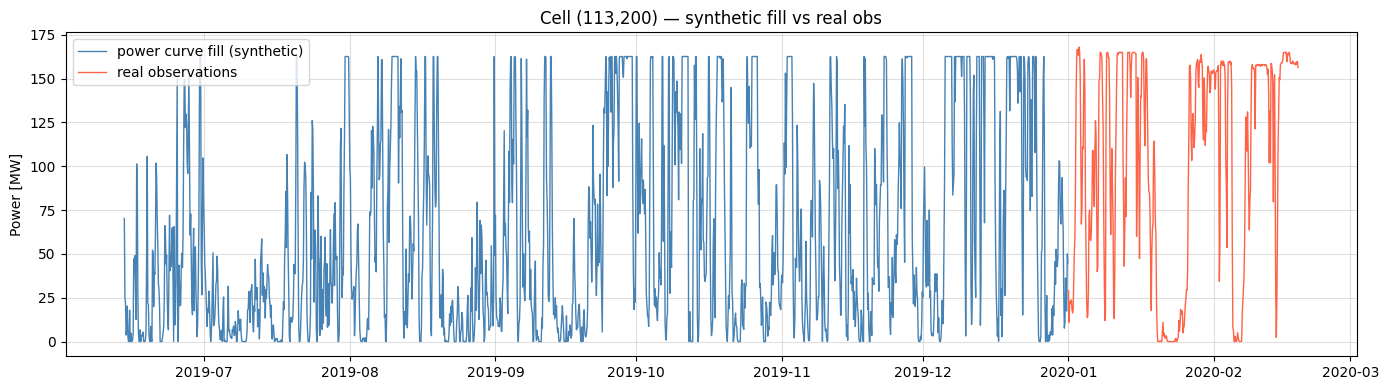

In [18]:

# Cell 7 — Quick verification: spot-check one farm cell (memory-safe)
import matplotlib.pyplot as plt

# # Free the large arrays from Cell 6 before loading anything new
# del power, ws100

cy, cx = farm_cells[2]

# Open both zarrs lazily — no .values yet
ds_src    = xr.open_zarr(SOURCE_ZARR, consolidated=False)
ds_filled = xr.open_zarr(OUT_ZARR,    consolidated=True)

# Load only the single (time,) slice for this cell
real_power = ds_src["power"].isel(y=cy, x=cx).values   # (time,)
fill_power = ds_filled["power"].isel(y=cy, x=cx).values  # (time,)
times      = ds_src["time"].values


# Separate the filled series into synthetic-only and real-only
was_nan    = np.isnan(real_power)   # True where original was NaN → power curve was used

synthetic_only = fill_power.copy()
synthetic_only[~was_nan] = np.nan   # mask out timesteps where real obs existed

sl = slice(13000, 15000)
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(times[sl], synthetic_only[sl], color="steelblue", lw=1,
        label="power curve fill (synthetic)")
ax.plot(times[sl], real_power[sl], color="tomato", lw=1,
        label="real observations")

ax.set_title(f"Cell ({cy},{cx}) — synthetic fill vs real obs")
ax.set_ylabel("Power [MW]")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
